# 🎯 08 · YOLO 系列目标检测详解（v1 → v11 全演进 · 故事版）

> 上一篇 `04-目标检测` 给你备好了**零件**（IoU/NMS/anchor/mAP）；这一篇把这些零件装成
> **一部 10 年的技术进化史**：为什么 YOLO 从「7×7 网格」一路进化到「无锚框 + 分布回归」，
> 每一代解决上一个痛点、又埋下下一个伏笔。
>
> 阅读方式：按「**痛点 → 方案 → 新痛点**」的故事线走，把每一代的动机先记下，再背结构与数字。
> 下一篇 `09-U-Net系列` 是像素级任务的同类故事（分割家族），再下一篇 `10-SAM` 是视觉基础模型时代。

> 🧩 **一句话主线**：一个框怎么描述？
> v1 直接回归「格内偏移 + 相对宽高」→ v2 引入 **anchor**（回归变成小偏移）→
> v3 上 **多尺度 FPN**（大小物体分开管）→ v4/v5 把训练配方做极致 → v6/v7 卷效率 →
> v8 回归 **anchor-free + 分布回归** → v9/v10/v11 卷梯度信息与注意力。

## §0 前情提要：检测的三次思想跃迁（知识链起点）

**任务定义**：检测 = 分类 + 定位，输出不定数量的 $(x_1,y_1,x_2,y_2,\text{class},\text{conf})$。

**三次跃迁（这就是全部故事线）**：

| 范式 | 代表 | 思想 | 代价 |
|---|---|---|---|
| 滑动窗口 | 2012 前 | 全图滑窗+分类 | 计算爆炸、窗口要试无数尺寸 |
| 两阶段 | R-CNN→Faster | **候选框**（搜索/学习）→ 逐框精修 | 慢（2k 框两次前向） |
| **一阶段** | **YOLO/SSD** | 全图一次前向直接回归框 | 精度低 → 靠十年迭代追平 |

> 本篇的主角是一阶段：**它的起步很朴素（v1），但十年的每一次修补都对应一个可讲的面试题**。
> 先把 v1 的朴素方案吃透，后面每代都只是"给这个朴素方案打补丁"。

## 第 1 幕 · YOLOv1（2016）：一个格子一个梦

**痛点**：Faster R-CNN 已经在 COCO 上很强，但 2k 个候选框两次前向，只能跑 5 FPS。
能不能**把整张图当成一个回归任务**，一次前向输出所有框？

**方案（朴素但天才）**：把 448×448 图切成 $7\times7$ 网格。
- 每个格子负责「中心落在自己范围内的物体」
- 每格预测 $B=2$ 个框：$(x,y,w,h,conf)$ —— $(x,y)$ 相对格子、$(w,h)$ 相对整图、$conf$ = 有物体的置信度
- 每格预测 $C=20$ 个类别分数（PASCAL）
- 输出张量：$7\times7\times30$（$B\cdot5+C = 2\times5+20$），**全图只有一次前向**

**为什么敢这么做**：把检测当成「结构化回归」——网络端到端地学「图像 → 框集合」。

In [1]:
import numpy as np

# ================= YOLOv1 损失：五项之和（手写 + 手算对账） =================
# 张量 (S,S,B,5+C)：每格每框预测 (x,y,w,h,conf) + C 个类别分数。
# 掩码约定：1_obj = 该格子有物体（负责任的框）；1_noobj = 没有（背景格子占绝大多数）。
def yolo_v1_loss(pred, target, S=2, B=1, C=3, lam_coord=5.0, lam_noobj=0.5):
    pred = np.asarray(pred, float); target = np.asarray(target, float)
    obj = target[..., 4:5]                                   # 1_obj 掩码
    noobj = 1.0 - obj                                        # 1_noobj 掩码
    # ① 中心坐标 MSE：λ_coord=5 —— 坐标直接决定框在哪，权重最大
    #    （为什么用平方：方便求导，且对大偏差惩罚更狠）
    xy = obj * (target[..., :2] - pred[..., :2]) ** 2
    # ② 宽高「开根号」MSE：对 √w、√h 求差再平方。
    #    为什么开根号：直接算 (w−ŵ)² 会让大框误差主导（大框 w≈0.9、小框 w≈0.1，
    #    同样 0.05 的绝对误差，大框损失是小框的 81 倍）；开根号把「相对误差」拉平。
    wh = obj * (np.sqrt(target[..., 2:4]) - np.sqrt(np.clip(pred[..., 2:4], 1e-6, None))) ** 2
    # ③ 有物体格子的置信度 MSE（conf = P(有物体)·IoU，v1 用两者的乘积当回归目标）
    conf = obj * (target[..., 4:5] - pred[..., 4:5]) ** 2
    # ④ 无物体格子的置信度 MSE：背景格子远多于前景，必须显式学「这里没东西」，
    #    但权重压到 λ_noobj=0.5，否则模型会被「全输出低置信度」带偏。
    conf_no = noobj * (target[..., 4:5] - pred[..., 4:5]) ** 2
    # ⑤ 类别 MSE：v1 连分类都用 MSE（v3 起换成 BCE，见第 3 幕）
    cls = obj * (target[..., 5:] - pred[..., 5:]) ** 2
    return (lam_coord * xy.sum() + lam_coord * wh.sum()
            + conf.sum() + lam_noobj * conf_no.sum() + cls.sum())

# ---- 手工小例子：只有格子 (0,0) 有物体，逐步手算与代码对账 ----
S, B, C = 2, 1, 3
pred = np.zeros((S, S, B, 5 + C))
target = np.zeros_like(pred)
pred[0, 0, 0] = [0.3, 0.4, 0.5, 0.5, 0.8, 0.6, 0.1, 0.3]   # 预测：框(0.3,0.4,0.5,0.5) 置信0.8 类别(0.6,0.1,0.3)
target[0, 0, 0] = [0.3, 0.4, 0.25, 0.25, 1.0, 1.0, 0.0, 0.0]  # 真值：框(0.3,0.4,0.25,0.25) 置信1 one-hot(1,0,0)
loss = yolo_v1_loss(pred, target, S, B, C)
# 手算：
#   ① 坐标差全 0 → 0
#   ② (√0.25−√0.5)² 的 w、h 两项 = 2·(0.5−√0.5)² ≈ 2×0.0429 = 0.0858，×λ_coord=5
#   ③ (1−0.8)² = 0.04
#   ④ 其余格子 pred/target 置信都是 0 → 0
#   ⑤ (1−0.6)²+(0−0.1)²+(0−0.3)² = 0.16+0.01+0.09 = 0.26
manual = 5.0 * 0.0 + 5.0 * 2 * (0.5 - np.sqrt(0.5)) ** 2 + 0.04 + 0.5 * 0.0 + 0.26
print('YOLOv1 loss = %.4f（手算 %.4f）' % (loss, manual))
assert abs(loss - manual) < 1e-6
print('对照通过：开根号项、λ_coord、λ_noobj 全部按设计生效')

YOLOv1 loss = 0.7289（手算 0.7289）
对照通过：开根号项、λ_coord、λ_noobj 全部按设计生效


### v1 的推理：编解码 + 置信度 + NMS 一条流水线

训练学的是「相对量」，推理要还原成「绝对框」：解码（网格偏移 → 图像坐标）→
按置信度过滤 → **NMS 去重**（同一物体多个框只留一个，NMS 原理见 04 篇）。
下面把 v1 的完整推理流水线手写一遍。

In [2]:
# ================= YOLOv1 编解码 + 推理流水线（手写） =================
S, IMG = 7, 448          # v1 真参数：7x7 网格、448 输入

def yolo_encode(box, S=S, IMG=IMG):
    # 绝对框 (x1,y1,x2,y2) -> (格子坐标 gx,gy, 格内偏移 cx_off,cy_off, 相对宽高 w_rel,h_rel)
    cx, cy = (box[0] + box[2]) / 2, (box[1] + box[3]) / 2   # 中心点
    w, h = box[2] - box[0], box[3] - box[1]
    gx, gy = int(cx / IMG * S), int(cy / IMG * S)            # 中心落在哪个格子
    cx_off, cy_off = cx / IMG * S - gx, cy / IMG * S - gy    # 格内偏移 ∈ [0,1)
    return gx, gy, cx_off, cy_off, w / IMG, h / IMG

def yolo_decode(gx, gy, cx_off, cy_off, w_rel, h_rel, S=S, IMG=IMG):
    # 逆运算：格子 + 偏移 -> 图像绝对坐标（训练目标就是让这组数逼近真值）
    cx = (gx + cx_off) / S * IMG
    cy = (gy + cy_off) / S * IMG
    w, h = w_rel * IMG, h_rel * IMG
    return np.array([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2])

def iou(a, b):
    ix1 = max(a[0], b[0]); iy1 = max(a[1], b[1]); ix2 = min(a[2], b[2]); iy2 = min(a[3], b[3])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    u = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / max(u, 1e-9)

def nms_boxes(boxes, scores, iou_thr=0.5):
    # NMS：按置信度降序，依次保留最高分框、抑制与其重叠>阈值的框（04 篇详解，这里内联复刻）
    order = np.argsort(-scores)
    keep = []
    while order.size:
        i = order[0]; keep.append(i)
        rest = order[1:]
        if rest.size:
            ious = np.array([iou(boxes[i], boxes[j]) for j in rest])
            order = rest[ious <= iou_thr]      # 只留与最高分框不重叠的
        else:
            order = rest
    return np.array(keep)

# ---- 推理流水线演示：3 个重叠预测 -> 阈值过滤 -> NMS 去重 ----
boxes = np.array([[100, 80, 200, 180], [110, 90, 210, 190], [300, 250, 380, 330]], float)  # 前两个重叠
scores = np.array([0.9, 0.7, 0.4])
keep0 = np.where(scores >= 0.3)[0]              # ① 置信度阈值过滤（保留 0.9/0.7/0.4）
keep = nms_boxes(boxes[keep0], scores[keep0])   # ② NMS：前两个 IoU 高 -> 只留 0.9 那个
print('解码示例：格子(3,2)偏移(0.4,0.4)宽高(0.6,0.5) ->', yolo_decode(3, 2, 0.4, 0.4, 0.6, 0.5))
print('推理保留框数: %d（期望 2：重叠的被 NMS 抑制）' % len(keep))
# 编解码 round-trip 一致性
for b in boxes:
    gx, gy, ox, oy, wr, hr = yolo_encode(b)
    assert np.allclose(yolo_decode(gx, gy, ox, oy, wr, hr), b)
assert len(keep) == 2
print('编解码 round-trip 通过 ✓')

解码示例：格子(3,2)偏移(0.4,0.4)宽高(0.6,0.5) -> [ 83.2  41.6 352.  265.6]
推理保留框数: 2（期望 2：重叠的被 NMS 抑制）
编解码 round-trip 通过 ✓


### v1 的四个痛点（记住这页，v2/v3 全是来补窟窿的）

1. **一格一物**：两个物体中心落在同一格子 → 只能报一个（重叠物体无解）
2. **小物体漏检**：7×7=49 个格子对大图上的小物体太稀疏（小猫只有几个像素）
3. **框数固定**：每格固定 2 个框，物体多时框不够、物体少时浪费
4. **定位粗糙**：$(x,y)$ 直接回归绝对坐标难收敛；宽高比例没先验

> 🔄 **转折点**：第 2 个痛点（小物体）和第 4 个痛点（定位）直接催生了 v2 的 **anchor**。

## 第 2 幕 · YOLOv2（2017）：anchor —— 给回归一个「起点」

**痛点**：直接回归任意框的坐标 → 收敛慢、框的比例千奇百怪。

**方案**：**先验框（anchor）**。对训练集 GT 框的宽高做聚类，得到 $K$ 个「常见形状」；
网络不再回归绝对坐标，而是回归「相对 anchor 的小偏移」：
$$\hat{x} = a_x + t_x \cdot a_w,\quad \hat{w} = a_w \cdot e^{t_w}$$

**为什么用 K-Means + IoU 距离**：欧氏距离对大框敏感（大框差 0.1 和小框差 0.1 的欧氏距离一样，
但形状上差很多）；IoU 衡量的是**形状相似度**，与尺寸解耦。

聚类出的 anchor 宽高（应各代表一个形状簇）:
  w=0.1727 h=0.0541（ratio=3.19）
  w=0.0882 h=0.0816（ratio=1.08）
  w=0.0529 h=0.1672（ratio=0.32）


sklearn(欧氏) 中心: [[0.0536 0.1861]
 [0.0848 0.084 ]
 [0.184  0.0546]]


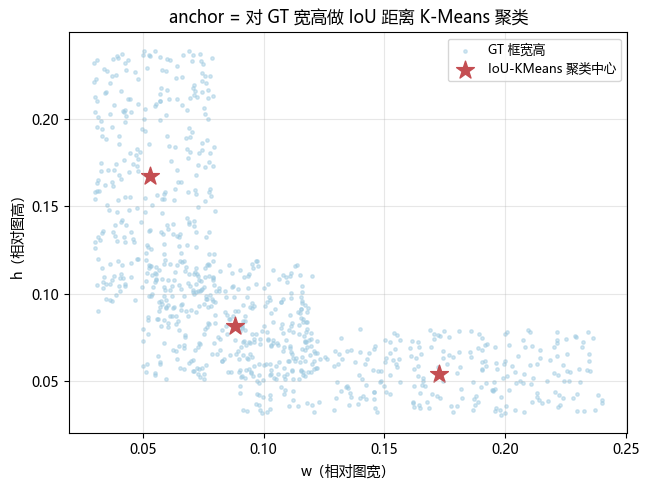

In [3]:
# ================= YOLOv2 的 anchor：手写 K-Means（IoU 距离） + sklearn 对照 =================
def kmeans_wh(wh, K=5, iters=50, seed=0):
    # wh: (N,2) 的 (w,h)；返回 K 个聚类中心（就是 anchor 的宽高）
    rng = np.random.default_rng(seed)
    centers = wh[rng.choice(len(wh), K, replace=False)].astype(float)  # 随机抽 K 个真值框当初始中心
    for _ in range(iters):
        # 距离 = 1 − IoU（把宽高当中心对齐的两个框算重叠）：形状越像距离越小
        a = wh[:, None, :]                    # (N,1,2)
        c = centers[None, :, :]               # (1,K,2)
        inter = np.minimum(a, c)[..., 0] * np.minimum(a, c)[..., 1]    # 重叠宽 × 重叠高
        union = a[..., 0] * a[..., 1] + c[..., 0] * c[..., 1] - inter
        dist = 1 - inter / np.maximum(union, 1e-9)
        assign = np.argmin(dist, axis=1)      # 每个框归到最近的锚框簇
        for k in range(K):                    # 重算中心 = 该簇框宽高的均值（EM 风格迭代）
            if np.any(assign == k):
                centers[k] = wh[assign == k].mean(axis=0)
    return centers

# 合成 GT 宽高：三种形状簇（瘦长 / 正方 / 扁宽）——聚类应能找回这三种比例
rng = np.random.default_rng(3)
wh_gt = np.vstack([
    rng.uniform(0.03, 0.08, (300, 2)) * [3, 1],   # 瘦长：w >> h
    rng.uniform(0.05, 0.12, (300, 2)),            # 正方：w ≈ h
    rng.uniform(0.03, 0.08, (300, 2)) * [1, 3],   # 扁宽：w << h
])
centers = kmeans_wh(wh_gt, K=3, seed=0)
print('聚类出的 anchor 宽高（应各代表一个形状簇）:')
for w, h in centers:
    print('  w=%.4f h=%.4f（ratio=%.2f）' % (w, h, w / h))
assert centers.shape == (3, 2) and np.all(centers > 0)
ratios = centers[:, 0] / centers[:, 1]
assert ratios.max() > 1.5 and ratios.min() < 1 / 1.5 and np.any(np.abs(ratios - 1) < 0.5)

# ---- 对照：sklearn KMeans（欧氏距离）会怎样？ ----
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(wh_gt)
print('sklearn(欧氏) 中心:', np.round(km.cluster_centers_, 4))
# 结论：欧氏距离偏向大框，聚类结果被大框带偏；这就是 YOLO 坚持 IoU 距离的原因

# ========== 图：GT 宽高散点 + IoU 距离聚类中心 ==========
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
fig, ax = plt.subplots(figsize=(6.6, 5.0))
ax.scatter(wh_gt[:, 0], wh_gt[:, 1], s=6, alpha=0.45, color='#9ecae1', label='GT 框宽高')
ax.scatter(centers[:, 0], centers[:, 1], s=180, marker='*', color='#C44E52', label='IoU-KMeans 聚类中心')
ax.set_xlabel('w（相对图宽）'); ax.set_ylabel('h（相对图高）')
ax.set_title('anchor = 对 GT 宽高做 IoU 距离 K-Means 聚类', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### anchor 怎么用：偏移回归的编解码（v2/v3 的实现核心）

聚类只回答了「先验形状从哪来」，真正让网络学的是**偏移回归**：
- 中心：$\hat{c}_x = \sigma(t_x) + \text{grid}_x$ —— 输出过 sigmoid 被压进格子内（不会飘到别的格子）
- 宽高：$t_w = \log(w / a_w)$，解码 $\hat{w} = a_w e^{t_w}$

**为什么宽高用 log/exp**：① $e^{t}$ 恒为正 → 网络无论输出什么符号都不会出现负宽高；
② log 把「宽高比」变成「线性距离」——目标从「预测绝对像素」降维成「预测一个很小的乘性修正」，
回归任务变简单（这是 anchor 方法比 v1 直接回归绝对框好收敛的根本原因）。

In [4]:
# ================= anchor 编解码（手写 + 手算 + round-trip） =================
def anchor_encode(box_wh, anchor_wh):
    # box_wh/(anchor_wh): gt 相对锚框宽高 -> log 空间偏移（锚框是"起点"）
    return np.log(np.clip(box_wh / anchor_wh, 1e-6, None))

def anchor_decode(t, anchor_wh):
    # 解码：锚框宽高 × e^t（训练目标就是让 t 逼近 encode 结果）
    return anchor_wh * np.exp(t)

# 手算：anchor w=80，GT w=60 → t_w = ln(60/80) = ln(0.75) ≈ -0.2877；h: 50/80 → -0.4700
a = np.array([80.0, 80.0]); box = np.array([60.0, 50.0])
t = anchor_encode(box, a)
print('t =', np.round(t, 4), '（手算 ln(0.75)=%.4f, ln(0.625)=%.4f）' % (np.log(0.75), np.log(0.625)))
assert abs(t[0] - np.log(0.75)) < 1e-9 and abs(t[1] - np.log(0.625)) < 1e-9
assert np.allclose(anchor_decode(t, a), box)          # round-trip：encode 后 decode 回原框
print('round-trip: 60/50 ->', np.round(anchor_decode(t, a), 4), '✓')

# 中心编码：归一化坐标 -> 格内偏移（v3 起输出过 sigmoid，训练目标同样归一化）
def center_encode(cx, cy, grid_x, grid_y, S=13):
    # cx/cy 为归一化坐标 [0,1]；grid 是中心所在格子索引
    return cx * S - grid_x, cy * S - grid_y
off = center_encode(0.41, 0.27, 5, 3, S=13)
print('中心编码：归一化 (0.41,0.27) 落格子 (5,3) → 格内偏移', np.round(off, 3))
assert np.allclose(off, (0.33, 0.51), atol=0.01)
print('要点：网络从不直接输出像素坐标，只输出「格内偏移 + log 宽高比」——回归的都是小量')

t = [-0.2877 -0.47  ] （手算 ln(0.75)=-0.2877, ln(0.625)=-0.4700）
round-trip: 60/50 -> [60. 50.] ✓
中心编码：归一化 (0.41,0.27) 落格子 (5,3) → 格内偏移 [0.33 0.51]
要点：网络从不直接输出像素坐标，只输出「格内偏移 + log 宽高比」——回归的都是小量


### v2 的其余手术（每个都是一句话考点）

| 手术 | 解决什么 | 一句话原理 |
|---|---|---|
| **BatchNorm** | 训练不稳、收敛慢 | 每层输出按 batch 统计归一化 → 分布稳定、可大步长（下文手写对照） |
| **高分辨率微调** | 小物体 | 预训练 448 → 检测阶段 480（分辨率越高小物体越清楚） |
| **多尺度训练** | 尺度鲁棒 | 每 10 batch 随机换输入尺寸 320~608，模型自适应各种分辨率 |
| **Darknet-19** | 速度 | 19 层卷积（借鉴 VGG 堆叠 + 全卷积），比 VGG 快一个量级 |
| **passthrough 层** | 细粒度特征 | 把 26×26 浅层特征拼进 13×13 深层 → 小物体细节（v3 的 FPN 雏形） |

In [5]:
import torch
import torch.nn as nn

# ================= 手写 BatchNorm 前向（训练模式） + torch 数值对照 =================
# BN 做的事：对每个通道，用 batch 均值/方差归一化，再乘可学习 γ、加 β：
#   x̂ = (x − μ_c) / √(σ_c² + ε)，  y = γ·x̂ + β
# 为什么能加速收敛：激活分布不再随前层权重变化而漂移（内部协变量漂移），
# 每层输入分布稳定 → 学习率可以更大、初始化可以不那么讲究。
def batchnorm_forward(x, gamma, beta, eps=1e-5):
    # x: (N,C,H,W)；γ/β: (C,)。训练模式：统计来自当前 batch。
    mean = x.mean(axis=(0, 2, 3), keepdims=True)      # 每个通道一个均值 (1,C,1,1)
    var = x.var(axis=(0, 2, 3), keepdims=True)         # 每个通道一个方差（无偏与否只差 n/(n-1)）
    xhat = (x - mean) / np.sqrt(var + eps)             # 归一化：分布 → 均值0方差1
    return gamma.reshape(1, -1, 1, 1) * xhat + beta.reshape(1, -1, 1, 1)

torch.manual_seed(0)
xt = torch.randn(2, 3, 8, 8)
bn = nn.BatchNorm2d(3).train()                          # 训练模式：用 batch 统计（γ=1、β=0 默认）
with torch.no_grad():
    out_t = bn(xt)
out_np = batchnorm_forward(xt.numpy(), np.ones(3), np.zeros(3))
err = np.abs(out_np - out_t.numpy()).max()
print('手写 BN 前向 vs torch 最大误差: %.2e' % err)
assert err < 1e-5
# 演示「内部协变量漂移」：两批分布差异很大的数据，BN 后都被拉回同一分布
x_a = np.random.default_rng(1).normal(0.2, 1.5, (4, 3, 8, 8))   # 批 A：均值 0.2 方差 1.5
x_b = np.random.default_rng(2).normal(3.0, 0.3, (4, 3, 8, 8))   # 批 B：均值 3.0 方差 0.3
print('无 BN：批 A 均值 %.2f 方差 %.2f | 批 B 均值 %.2f 方差 %.2f（分布漂移大）' % (
    x_a.mean(), x_a.var(), x_b.mean(), x_b.var()))
o_a = batchnorm_forward(x_a, np.ones(3), np.zeros(3))
o_b = batchnorm_forward(x_b, np.ones(3), np.zeros(3))
print('有 BN：批 A 输出均值 %.4f 方差 %.4f | 批 B 输出均值 %.4f 方差 %.4f（都被拉回同分布）' % (
    o_a.mean(), o_a.var(), o_b.mean(), o_b.var()))
assert abs(o_a.mean()) < 1e-2 and abs(o_b.mean()) < 1e-2

手写 BN 前向 vs torch 最大误差: 4.77e-07
无 BN：批 A 均值 0.11 方差 2.14 | 批 B 均值 2.99 方差 0.09（分布漂移大）
有 BN：批 A 输出均值 0.0000 方差 1.0000 | 批 B 输出均值 0.0000 方差 0.9999（都被拉回同分布）


## 第 3 幕 · YOLOv3（2018）：多尺度 FPN —— 大小物体各就各位

**痛点**：v2 的 passthrough 只拼了一个浅层，小物体依然漏检；物体尺度差异大，单尺度特征顾此失彼。

**方案**：**特征金字塔（FPN）**——从 backbone 抽出三个尺度（stride 8/16/32 → 52/26/13 网格），
**大特征图管小物体**（分辨率高、细节多），小特征图管大物体（语义强）。

- **Darknet-53**：53 层卷积（残差思想），比 ResNet-152 快 2 倍
- **9 个 anchor** 按尺度分：小 anchor → stride 8 的特征图，中 → 16，大 → 32
- **中心约束**：$c_x = \sigma(t_x)+\text{grid}_x$ —— sigmoid 把偏移压进格子内（不会飘到别的格子）
- **多标签**：类别用 sigmoid + 二元 CE（一个物体可以同时是 person 和 woman），不再 softmax 互斥
- **对象性**：每个 anchor 预测「有没有物体」单独用 BCE（v1 用回归，v3 换成二分类更稳）

In [6]:
# ================= YOLOv3 三尺度 + anchor 分配模拟 =================
# 输入 416：stride 8/16/32 → 特征图 52/26/13。anchor 按「负责尺度」分组：
anchors_3s = {8:  [(10, 13), (16, 30), (33, 23)],
              16: [(30, 61), (62, 45), (59, 119)],
              32: [(116, 90), (156, 198), (373, 326)]}
print('YOLOv3 三尺度特征图与 anchor 分组（416 输入，COCO 80 类）:')
for st, as_ in sorted(anchors_3s.items()):
    fm = 416 // st
    print('  stride=%2d → %3d×%3d 网格，anchor=%s，输出通道 %d' %
          (st, fm, fm, as_, 3 * (5 + 80)))

# ---- GT 按面积分配到尺度（小物体→大特征图）：模拟一批 GT ----
rng = np.random.default_rng(0)
n = 40
areas = np.exp(rng.uniform(np.log(8 ** 2), np.log(200 ** 2), n))   # 面积 8²~200² 像素
def assign_scale(area, img=416):
    # 经验阈值：面积 < (32²) 给 stride8；< (96²) 给 stride16；否则 stride32
    if area < 32 ** 2: return 8
    if area < 96 ** 2: return 16
    return 32
counts = {s: 0 for s in (8, 16, 32)}
for a in areas:
    counts[assign_scale(a)] += 1
print('40 个随机 GT 的尺度分配: stride8(小物体)=%d, stride16=%d, stride32(大物体)=%d' %
      (counts[8], counts[16], counts[32]))
assert counts[8] + counts[16] + counts[32] == n and counts[8] > 0 and counts[32] > 0

# ---- 3×3 卷积堆叠与 stride 的关系：为什么 stride8 需要 2 次 stride2 卷积 ----
print('stride 是 backbone 逐层 stride 的乘积：2×2×2=8，4 次 2=16，5 次 2=32')

YOLOv3 三尺度特征图与 anchor 分组（416 输入，COCO 80 类）:
  stride= 8 →  52× 52 网格，anchor=[(10, 13), (16, 30), (33, 23)]，输出通道 255
  stride=16 →  26× 26 网格，anchor=[(30, 61), (62, 45), (59, 119)]，输出通道 255
  stride=32 →  13× 13 网格，anchor=[(116, 90), (156, 198), (373, 326)]，输出通道 255
40 个随机 GT 的尺度分配: stride8(小物体)=15, stride16=15, stride32(大物体)=10
stride 是 backbone 逐层 stride 的乘积：2×2×2=8，4 次 2=16，5 次 2=32


### FPN 自顶向下融合：深层语义注入浅层（v3 多尺度的实现）

三个独立特征图还不够——**浅层（52×52）细节多但语义弱**，深层（13×13）语义强但分辨率低。
FPN 的做法：**自顶向下逐级上采样相加**：
$$P_4 = \text{conv}_{1\times1}(C_4) + \text{up}(P_5),\qquad P_3 = \text{conv}_{1\times1}(C_3) + \text{up}(P_4)$$

每个输出头因此同时拿到「同级细节 + 深层语义」。v4 再加**自底向上**（PANet）把细节送回深层，
形成双向信息流。

In [7]:
# ================= FPN 自顶向下 + PANet 自底向上（torch 形状推演） =================
import torch
import torch.nn as nn
torch.manual_seed(0)
# backbone 三支（YOLO 命名 C3/C4/C5 = stride 8/16/32：空间 52/26/13，通道 256/512/1024）
C3 = torch.randn(2, 256, 52, 52)     # 最浅：细节最多（管小物体）
C4 = torch.randn(2, 512, 26, 26)     # 中层
C5 = torch.randn(2, 1024, 13, 13)    # 最深：语义最强（管大物体）

# ---- 自顶向下：深层上采样 x2，逐级 add 给浅层 ----
up = nn.Upsample(scale_factor=2, mode='nearest')
p5 = nn.Conv2d(1024, 128, 1)(C5)                              # 最深层先投影（FPN 起点）
p4 = nn.Conv2d(512, 128, 1)(C4) + up(p5)                      # 26 = 13×2：26x26 细节 + 13x13 语义
p3 = nn.Conv2d(256, 128, 1)(C3) + up(p4)                      # 52 = 26×2：52x52 再收一层语义
print('FPN 输出（各接一个检测头）:', tuple(p3.shape), tuple(p4.shape), tuple(p5.shape))
assert tuple(p3.shape) == (2, 128, 52, 52) and tuple(p4.shape) == (2, 128, 26, 26) and tuple(p5.shape) == (2, 128, 13, 13)

# ---- 自底向上（v4 的 PANet）：细节再送回深层 ----
down = nn.Conv2d(128, 128, 3, stride=2, padding=1)   # 分辨率减半的卷积（52->26->13）
n3 = p3
n4 = p4 + down(n3)                                   # 52 -> 26（细节注入中层）
n5 = p5 + down(n4)                                   # 26 -> 13（细节注入深层）
print('PANet 自底向上后:', tuple(n3.shape), tuple(n4.shape), tuple(n5.shape))
assert tuple(n4.shape) == (2, 128, 26, 26) and tuple(n5.shape) == (2, 128, 13, 13)
print('要点：FPN 给浅层补语义、PANet 给深层补细节 —— 双向信息流是 v3/v4 多尺度效果好的实现根基')

FPN 输出（各接一个检测头）: (2, 128, 52, 52) (2, 128, 26, 26) (2, 128, 13, 13)
PANet 自底向上后: (2, 128, 52, 52) (2, 128, 26, 26) (2, 128, 13, 13)
要点：FPN 给浅层补语义、PANet 给深层补细节 —— 双向信息流是 v3/v4 多尺度效果好的实现根基


In [8]:
# ================= YOLOv3 的损失核心：对象性 BCE + 类别 BCE（手写 + 手算） =================
# v3 每尺度每 anchor 独立预测：对象性（1 维，sigmoid+BCE）+ 类别（C 维，sigmoid+多标签 BCE）。
# 分配规则：每个 GT 中心所在格子，取与之 IoU 最大的 anchor 为正样本（负责它）。

def bce_loss(pred_prob, target):
    # 二元交叉熵：−[t·log p + (1−t)·log(1−p)]。p 是 sigmoid 后的概率。
    eps = 1e-7
    return -(target * np.log(pred_prob + eps) + (1 - target) * np.log(1 - pred_prob + eps))

# 手算小例子：一个 GT 落在 13x13 网格 (5,7)，与 3 个候选 anchor 的 IoU = (0.1, 0.7, 0.2)
# → 选 anchor 2（IoU 最大）为正样本：对象性目标=1，类别目标=one-hot（人）
ious = np.array([0.1, 0.7, 0.2])
best = int(np.argmax(ious))                     # 正样本 anchor = IoU 最大的那个
pred_conf = np.array([0.3, 0.6, 0.1])           # 三个 anchor 预测的对象性 logit（假设已 sigmoid）
pred_cls = np.array([0.4, 0.6, 0.2])            # 预测的「人」概率（多标签之一）
# 对象性损失：只有正样本 anchor 参与（目标 1），其余为背景（目标 0）
l_obj = bce_loss(pred_conf[best], 1.0) + sum(bce_loss(pred_conf[j], 0.0) for j in range(3) if j != best)
l_cls = bce_loss(pred_cls[best], 1.0)           # 类别损失只看正样本
print('正样本 anchor = %d（IoU=%.1f 最大）' % (best, ious[best]))
print('对象性 BCE = %.4f | 类别 BCE = %.4f' % (l_obj, l_cls))
# 手算核对：l_obj = −log(0.6) − log(0.7) − log(0.9) ≈ 0.511+0.357+0.105 = 0.973
manual_obj = -np.log(0.6) - np.log(1 - 0.3) - np.log(1 - 0.1)
manual_cls = -np.log(0.6)
assert abs(l_obj - manual_obj) < 1e-6 and abs(l_cls - manual_cls) < 1e-6
print('手算一致 ✓（背景 anchor 也要学「没东西」——与 v1 的 λ_noobj 同源的思想）')

正样本 anchor = 1（IoU=0.7 最大）
对象性 BCE = 0.9729 | 类别 BCE = 0.5108
手算一致 ✓（背景 anchor 也要学「没东西」——与 v1 的 λ_noobj 同源的思想）


## 第 4 幕 · YOLOv4（2020）：把「训练配方」做到极致

**痛点**：v3 结构已定，但**训练技巧**没有拉满——同样结构，配方不同效果差 5 个点。

**方案（v4 是配方集大成者）**：

| 配方 | 作用 |
|---|---|
| **CSPDarknet-53** | CSP：通道切两半、一半直连一半卷积 → 减计算 + 梯度流动更好 |
| **Mish 激活** | 平滑激活（比 ReLU 梯度更稳），分类任务普遍 +1~2 点 |
| **PANet 融合** | FPN 自顶向下后，**再自底向上补一条** → 小物体信息也传到高层 |
| **Mosaic 增强** | 4 张图拼 1 张 → 小目标样本翻倍 + BN 统计更稳（下文手写） |
| **CIoU 损失** | IoU + 中心距 + 宽高比三重惩罚（下文手写） |
| **自对抗训练** | 先让网络「骗自己」制造难样本，再正常训练 |

> 面试常问：**v4 最大贡献是网络还是配方？** 答：配方。网络是 v3 的改造，配方才是收益大头。

拼接后画布形状: (64, 64, 3) | 检测到物体框数: 4
标签框（y1,x1,y2,x2,cat）:
   (np.int64(0), np.int64(0), np.int64(31), np.int64(31), 0)
   (np.int64(0), np.int64(36), np.int64(31), np.int64(63), 1)
   (np.int64(44), np.int64(20), np.int64(63), np.int64(31), 2)
   (np.int64(32), np.int64(32), np.int64(63), np.int64(63), 0)


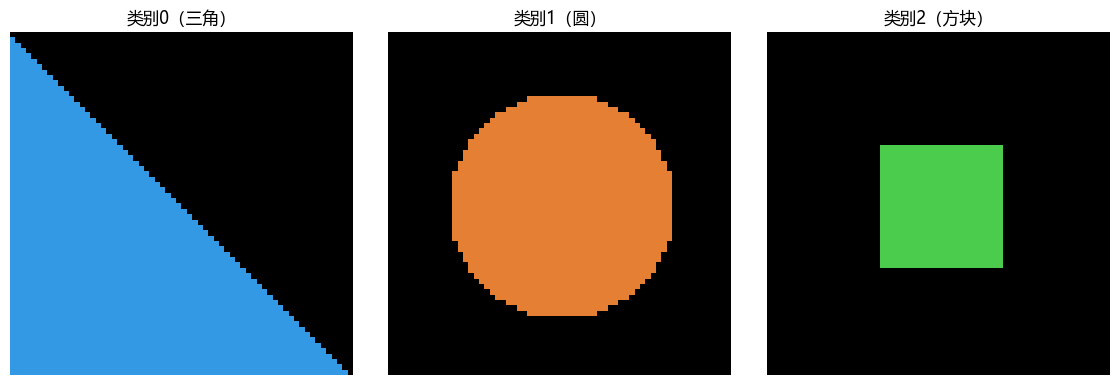

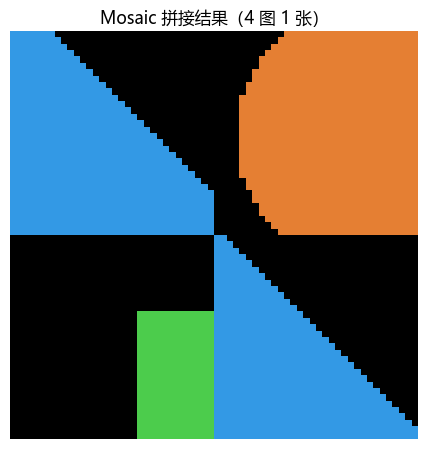

Mosaic 效果：小目标密度提升（原本 1/4 图的大小变成 1/16 的小目标）→ 小物体训练样本激增


In [9]:
# ================= Mosaic 增强手写：4 张图拼 1 张（v4/v5 的训练神器） =================
rng = np.random.default_rng(0)

def synth_img(cat, size=64):
    # 合成三类图：0=左下亮三角 1=右上半圆 2=中心方块（模拟不同类别）
    yy, xx = np.mgrid[0:size, 0:size]
    if cat == 0:
        mask = xx < yy                       # 左下三角
    elif cat == 1:
        mask = (xx - size // 2) ** 2 + (yy - size // 2) ** 2 < (size // 3) ** 2   # 圆
    else:
        mask = (abs(xx - size // 2) < size // 5) & (abs(yy - size // 2) < size // 5)  # 方块
    img = np.zeros((size, size, 3))
    img[mask] = np.array([0.2, 0.6, 0.9]) if cat == 0 else (np.array([0.9, 0.5, 0.2]) if cat == 1 else np.array([0.3, 0.8, 0.3]))
    return img, mask

size = 64
canvas = np.zeros((size, size, 3))
label_boxes = []                               # 拼接后每个物体的框（yolo 风格）
for k, cat in enumerate([0, 1, 2, 0]):         # 4 张不同/重复类别图
    img, mask = synth_img(cat)
    # 随机从原图裁一块（Mosaic 的思想：裁剪后拼接 → 局部信息更密集）
    y0 = rng.integers(0, size // 2); x0 = rng.integers(0, size // 2)
    crop = img[y0:y0 + size // 2, x0:x0 + size // 2]
    py = (k // 2) * (size // 2); px = (k % 2) * (size // 2)      # 4 个象限的放置位置
    canvas[py:py + size // 2, px:px + size // 2] = crop
    m = mask[y0:y0 + size // 2, x0:x0 + size // 2]
    ys, xs = np.where(m)
    if len(ys):
        label_boxes.append((py + ys.min(), px + xs.min(), py + ys.max(), px + xs.max(), cat))
print('拼接后画布形状:', canvas.shape, '| 检测到物体框数:', len(label_boxes))
assert canvas.shape == (size, size, 3) and len(label_boxes) == 4
print('标签框（y1,x1,y2,x2,cat）:')
for b in label_boxes:
    print('  ', b)

# ========== 图：4 张原图 + 拼接结果 ==========
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8))
srcs = [synth_img(c)[0] for c in (0, 1, 2)]
for ax, im, t in zip(axes[:3], srcs, ['类别0（三角）', '类别1（圆）', '类别2（方块）']):
    ax.imshow(im); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()
fig2, ax2 = plt.subplots(figsize=(4.6, 4.6))
ax2.imshow(canvas); ax2.set_title('Mosaic 拼接结果（4 图 1 张）', fontsize=12); ax2.axis('off')
plt.tight_layout(); plt.show()
print('Mosaic 效果：小目标密度提升（原本 1/4 图的大小变成 1/16 的小目标）→ 小物体训练样本激增')

IoU = 0.6667（手算 320/480=0.6667），CIoU = 0.6503


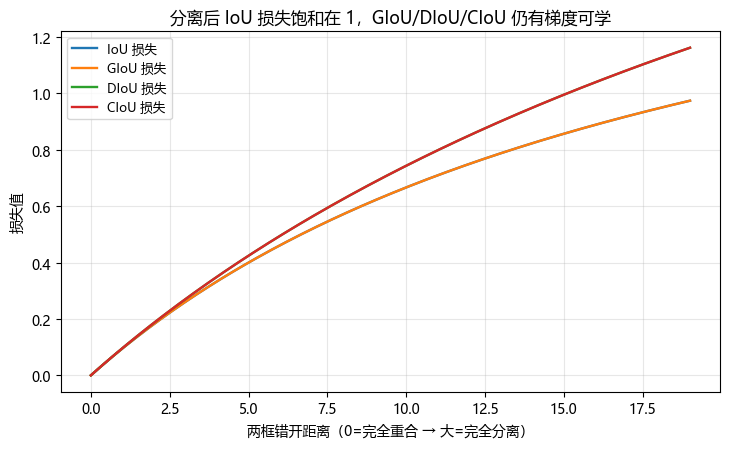

In [10]:
# ================= CIoU 手写（v4/v5 回归损失，三代惩罚逐行注释） =================
def iou(b1, b2):
    ix1 = max(b1[0], b2[0]); iy1 = max(b1[1], b2[1])
    ix2 = min(b1[2], b2[2]); iy2 = min(b1[3], b2[3])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    a1 = (b1[2]-b1[0])*(b1[3]-b1[1]); a2 = (b2[2]-b2[0])*(b2[3]-b2[1])
    return inter / max(a1 + a2 - inter, 1e-9)

def giou(b1, b2):
    iou_v = iou(b1, b2)
    c_x1 = min(b1[0], b2[0]); c_y1 = min(b1[1], b2[1]); c_x2 = max(b1[2], b2[2]); c_y2 = max(b1[3], b2[3])
    area_c = (c_x2 - c_x1) * (c_y2 - c_y1)
    ix1 = max(b1[0], b2[0]); iy1 = max(b1[1], b2[1]); ix2 = min(b1[2], b2[2]); iy2 = min(b1[3], b2[3])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_u = (b1[2]-b1[0])*(b1[3]-b1[1]) + (b2[2]-b2[0])*(b2[3]-b2[1]) - inter
    return iou_v - (area_c - area_u) / max(area_c, 1e-9)   # 惩罚「C 里没被框盖住的空隙」

def diou(b1, b2):
    iou_v = iou(b1, b2)
    c_x1 = min(b1[0], b2[0]); c_y1 = min(b1[1], b2[1]); c_x2 = max(b1[2], b2[2]); c_y2 = max(b1[3], b2[3])
    c = (c_x2 - c_x1) ** 2 + (c_y2 - c_y1) ** 2
    b1c = ((b1[0]+b1[2])/2, (b1[1]+b1[3])/2); b2c = ((b2[0]+b2[2])/2, (b2[1]+b2[3])/2)
    rho2 = (b1c[0]-b2c[0]) ** 2 + (b1c[1]-b2c[1]) ** 2
    return iou_v - rho2 / max(c, 1e-9)

def ciou(b1, b2):
    iou_v = iou(b1, b2)
    c_x1 = min(b1[0], b2[0]); c_y1 = min(b1[1], b2[1]); c_x2 = max(b1[2], b2[2]); c_y2 = max(b1[3], b2[3])
    c = (c_x2 - c_x1) ** 2 + (c_y2 - c_y1) ** 2
    b1c = ((b1[0]+b1[2])/2, (b1[1]+b1[3])/2); b2c = ((b2[0]+b2[2])/2, (b2[1]+b2[3])/2)
    rho2 = (b1c[0]-b2c[0]) ** 2 + (b1c[1]-b2c[1]) ** 2
    # 宽高比一致性：v 衡量 (w1/h1) 与 (w2/h2) 的差异；α 让惩罚随 IoU 自动缩放（重叠越大越在意比例）
    w1 = b1[2]-b1[0]; h1 = b1[3]-b1[1]; w2 = b2[2]-b2[0]; h2 = b2[3]-b2[1]
    v = (4 / np.pi ** 2) * (np.arctan(w1 / h1) - np.arctan(w2 / h2)) ** 2
    alpha = v / max((1 - iou_v) + v, 1e-9)
    return iou_v - rho2 / max(c, 1e-9) - alpha * v

# 数值验证：两个同尺寸正方形左右错开 4 像素 → CIoU < IoU（中心距被惩罚；宽高比相同所以 v=0）
b1 = (10, 10, 30, 30); b2 = (14, 10, 34, 30)
print('IoU = %.4f（手算 320/480=0.6667），CIoU = %.4f' % (iou(b1, b2), ciou(b1, b2)))
assert abs(iou(b1, b2) - 320 / 480) < 1e-9 and ciou(b1, b2) < iou(b1, b2)

# ========== 图：IoU 系损失随「错开量」变化（分离时谁还有梯度） ==========
def loss_curves():
    sim, offs = 20, np.linspace(0, 19, 200)
    fig, ax = plt.subplots(figsize=(7.4, 4.6))
    for name, fn in [('IoU', iou), ('GIoU', giou), ('DIoU', diou), ('CIoU', ciou)]:
        ls = [1.0 - fn((0, 0, sim, sim), (d, 0, sim + d, sim)) for d in offs]
        ax.plot(offs, ls, lw=1.7, label=name + ' 损失')
    ax.set_xlabel('两框错开距离（0=完全重合 → 大=完全分离）'); ax.set_ylabel('损失值')
    ax.set_title('分离后 IoU 损失饱和在 1，GIoU/DIoU/CIoU 仍有梯度可学', fontsize=12)
    ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

loss_curves()

### v4 的两个结构手术：Mish 激活与 CSP 梯度切分（原理 + 实现）

**Mish**：$\text{Mish}(x) = x \cdot \tanh(\ln(1+e^x))$ —— 与 ReLU 相比，负区间**平滑非单调**，
梯度不会硬截断为 0，收敛更稳（很多分类任务白捡 1~2 个点）。

**CSP（Cross Stage Partial）**：输入沿通道切两半，**一半恒等直连、一半过卷积**再拼回：
$$x \to [x_{前半}, \; f(x_{后半})]$$
梯度因此有「恒等捷径」直通（不衰减）+「变换路径」学特征，双双受益——这就是 v4/v5 的
CSPDarknet 比纯 Darknet 强的地方。

Mish 手写 vs torch 最大误差: 8.88e-16


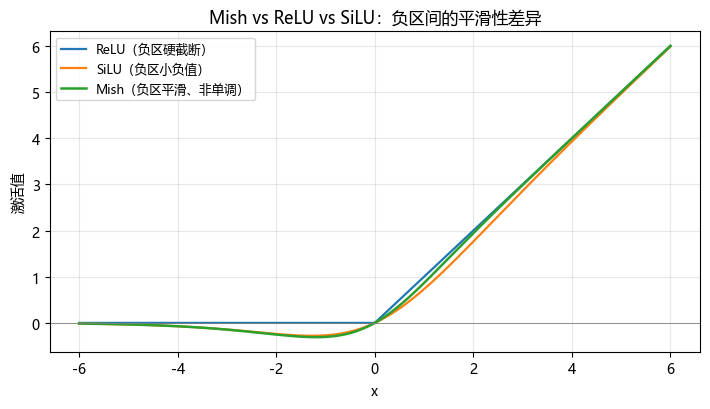

CSP: (2,128,16,16) -> 切 64+64 -> 一半卷积 -> 拼接 (2, 128, 16, 16)（参数量≈单路，梯度却双路）
为什么有效：路径 A 恒等直通（梯度不衰减），路径 B 学新表示 —— 两路梯度互补（面试一句话）


In [11]:
# ================= Mish 手写 + torch 对照 + CSP 通道切分（实现） =================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

def mish_np(x):
    # Mish = x·tanh(softplus(x)) = x·tanh(ln(1+e^x))：负区平滑、全局光滑、无硬截断
    return x * np.tanh(np.log1p(np.exp(x)))

xt = torch.linspace(-6, 6, 2000, dtype=torch.float64)
m_t = F.mish(xt).numpy()
m_np = mish_np(xt.numpy())
err = np.abs(m_t - m_np).max()
print('Mish 手写 vs torch 最大误差: %.2e' % err)
assert err < 1e-5

# ========== 图：ReLU / SiLU / Mish 曲线对比 ==========
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
x = np.linspace(-6, 6, 400)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(x, np.maximum(x, 0), lw=1.6, label='ReLU（负区硬截断）')
ax.plot(x, x / (1 + np.exp(-x)), lw=1.6, label='SiLU（负区小负值）')
ax.plot(x, mish_np(x), lw=1.8, label='Mish（负区平滑、非单调）')
ax.axhline(0, color='gray', lw=0.6)
ax.set_xlabel('x'); ax.set_ylabel('激活值')
ax.set_title('Mish vs ReLU vs SiLU：负区间的平滑性差异', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ---- CSP：通道切半，一半直连一半卷积（v4 CSPDarknet 的核心块） ----
torch.manual_seed(1)
xin = torch.randn(2, 128, 16, 16)
a, b = xin[:, :64], xin[:, 64:]                    # ① 沿通道切成两半（CSP 的『Partial』）
b = nn.Sequential(nn.Conv2d(64, 64, 1), nn.Conv2d(64, 64, 3, padding=1))(b)  # ② 一半学变换
out = torch.cat([a, b], dim=1)                     # ③ 拼回
print('CSP: (2,128,16,16) -> 切 64+64 -> 一半卷积 -> 拼接 %s（参数量≈单路，梯度却双路）' % (tuple(out.shape),))
assert tuple(out.shape) == (2, 128, 16, 16)
print('为什么有效：路径 A 恒等直通（梯度不衰减），路径 B 学新表示 —— 两路梯度互补（面试一句话）')

### 第 5 幕 · YOLOv5（2020）：没有论文的工业王者

**痛点**：v4 的论文代码不友好（C 风格、难部署），社区需要"开箱即用"。

**方案（工程学巅峰）**：Ultralytics 把检测做成了**一键工具**：
- **auto-anchor**：按数据集自动重新聚类 anchor（不用手动调）
- **超参进化**：网格搜索/遗传调 lr、mosaic 比例、损失权重
- **工程细节**：Mosaic 变体、缓存、AMP 混合精度、模型导出 ONNX/TFLite/TensorRT
- **模型谱系**：s/m/l/x 一档一档卖算力（同一结构不同深度宽度）

**为什么它最流行**：不是精度最高，而是**上手成本最低**——`pip install ultralytics` 三行代码训练。
> 面试观点题：**论文 vs 工程谁更重要？** v5 的答案：能落地的工程有时比新结构更有价值。

### v5 的 Focus 层（原理 + 实现）：开局就省一半算力

检测输入分辨率大（v5 常用 640），第一层直接从 3 通道卷到 32 通道太贵。
**Focus**：把输入隔像素采成 **4 个子图拼通道**——分辨率减半、通道 ×4，**信息零丢失**（每个像素都保留），
后续卷积在减半的分辨率上做，直接省一半计算量。

> 后续版本（v6/v7/v8）改回「stride2 卷积」等价替代：效果一样、实现更简单、部署更友好——
> 这也是"工程演进"的活例子。

In [12]:
# ================= v5 的 Focus 层：隔像素采样拼接（numpy 手写 + 信息无损验证） =================
def focus(x):
    # x: (B,C,H,W) -> (B,4C,H/2,W/2)：按奇偶行/列采 4 个子图，沿通道维拼接
    s1 = x[:, :, 0::2, 0::2]; s2 = x[:, :, 0::2, 1::2]
    s3 = x[:, :, 1::2, 0::2]; s4 = x[:, :, 1::2, 1::2]
    return np.concatenate([s1, s2, s3, s4], axis=1)

rng = np.random.default_rng(0)
xin = rng.normal(size=(2, 3, 8, 8))
f = focus(xin)
print('Focus: (2,3,8,8) -> %s（分辨率 8→4，通道 3→12）' % (f.shape,))
assert f.shape == (2, 12, 4, 4)

# 信息无损验证：4 个子图并集恰为完整原图（对比 09 篇的 patch merge——那里是 2x2 邻域拼，这里是隔像素采）
subs = [xin[:, :, 0::2, 0::2], xin[:, :, 0::2, 1::2], xin[:, :, 1::2, 0::2], xin[:, :, 1::2, 1::2]]
restored = np.stack(subs, axis=1)                 # (B,4,C,H/2,W/2)，与 f 的通道顺序一致
assert np.allclose(f.reshape(2, 4, 3, 4, 4), restored)
print('信息无损：4 个子图并集 = 完整原图 ✓（等价于 stride2 卷积的输入，但把"下采样"显式化）')

Focus: (2,3,8,8) -> (2, 12, 4, 4)（分辨率 8→4，通道 3→12）
信息无损：4 个子图并集 = 完整原图 ✓（等价于 stride2 卷积的输入，但把"下采样"显式化）


## 第 6 幕 · YOLOv6/v7（2022）：效率革命

**痛点**：检测头里**分类和回归共享一个特征**——这两个任务的"想要的东西"经常冲突
（分类要语义、回归要边界细节），耦合头互相干扰。

**方案 1（v6，美团）**：**解耦头**——分类走一条支路、回归走另一条，各学各的。
顺带：回归目标改成 **anchor-free 变体**（直接预测中心点到四边的距离，见 v8 详解）。

**方案 2（v7，台湾中央研究院）**：
- **E-ELAN**：把梯度路径织成网（多条旁路 → 梯度信息不衰减）
- **重参数化（RepConv）**：训练时多分支、推理时**融合成单卷积**（省算力，数学等价）
- **辅助头深监督**：浅层也接检测头拿梯度（深监督思想，与 U-Net++ 同源！见 09 篇）

In [13]:
# ================= 耦合头 vs 解耦头：形状推演（为什么解耦能缓解任务冲突） =================
import torch
import torch.nn as nn

torch.manual_seed(0)
feat = torch.randn(2, 256, 16, 16)   # backbone 输出的共享特征 (N,256,16,16)
C, D = 80, 4                          # 80 类、4 个回归量

# 耦合头：一个 1x1 卷积同时出分类(80)与回归(4) → 输出 84 通道（两个任务被迫共享表示）
coupled = nn.Conv2d(256, C + D, 1)
out_coupled = coupled(feat)

# 解耦头：分类 1x1→80、回归 1x1→4，两条支路各学各的（v6/v8 的做法）
cls_head = nn.Conv2d(256, C, 1)
reg_head = nn.Conv2d(256, D, 1)
out_cls, out_reg = cls_head(feat), reg_head(feat)

print('耦合头输出:', tuple(out_coupled.shape), '（84 通道：分类回归挤在一个张量）')
print('解耦头输出: 分类', tuple(out_cls.shape), ' + 回归', tuple(out_reg.shape), '（两条独立支路）')
assert out_coupled.shape == (2, 84, 16, 16) and out_cls.shape == (2, 80, 16, 16) and out_reg.shape == (2, 4, 16, 16)
print('要点：分类支路专注语义（这是什么），回归支路专注边界（框在哪）——互不干扰、各调各的损失')

耦合头输出: (2, 84, 16, 16) （84 通道：分类回归挤在一个张量）
解耦头输出: 分类 (2, 80, 16, 16)  + 回归 (2, 4, 16, 16) （两条独立支路）
要点：分类支路专注语义（这是什么），回归支路专注边界（框在哪）——互不干扰、各调各的损失


### v7 的重参数化（RepConv）：训练 3 分支，推理 1 个卷积（原理 + 实现）

**痛点**：多分支结构（ResNet 风格）训练好但推理慢——每层 3 条支路要算 3 次。

**方案（重参数化，re-parameterization）**：训练时保留多分支（学得好的关键），
推理前把分支**数学等价地融合**成一个卷积：
$$y = \underbrace{W_3*x + b_3}_{\text{3×3}} + \underbrace{W_1*x + b_1}_{\text{1×1}} + \underbrace{x}_{\text{恒等}} \;\Longrightarrow\; y = W'*x + b'$$

- 1×1 核 pad 到 3×3 中心 = 3×3；恒等 = 单位核放中心 → 三者相加成一个 $W'$
- 融合后推理 = **单次卷积**，计算量大幅下降，输出**逐位一致**（下面数值对照验证）

In [14]:
# ================= RepConv 融合（torch 数值对照：训练 3 分支 == 推理 1 卷积） =================
import torch
import torch.nn as nn
torch.manual_seed(0)
C, F = 8, 8
x = torch.randn(2, C, 6, 6)

conv3 = nn.Conv2d(C, F, 3, padding=1)     # 分支①：3x3
conv1 = nn.Conv2d(C, F, 1)                # 分支②：1x1
with torch.no_grad():
    y3 = conv3(x); y1 = conv1(x); y_id = x                     # 分支③：恒等（F=C 时）
    y_train = y3 + y1 + y_id                                   # 训练输出 = 三支路之和

    # ---- 融合：1x1 核 pad 到中心 + 单位核放中心 + 两者与 3x3 相加 ----
    k = conv3.weight.data.clone()
    k1_pad = torch.zeros(F, C, 3, 3); k1_pad[:, :, 1, 1] = conv1.weight.data[:, :, 0, 0]  # 1x1 -> 3x3
    k = k + k1_pad
    eye = torch.zeros(F, C, 3, 3); eye[:, :, 1, 1] = torch.eye(C)                        # 恒等 -> 单位核
    k = k + eye
    b = conv3.bias.data + conv1.bias.data                      # 三个偏置相加（恒等偏置为 0）

    fused = nn.Conv2d(C, F, 3, padding=1)
    fused.weight.data = k; fused.bias.data = b
    y_fused = fused(x)                                         # 推理输出 = 单卷积

err = (y_train - y_fused).abs().max().item()
print('训练 3 分支 vs 融合单卷积 最大误差: %.2e' % err)
assert err < 1e-5
print('对照通过：融合后输出与训练状态逐位一致（推理只跑 1 个卷积 → v7 部署提速的数学根基）')

训练 3 分支 vs 融合单卷积 最大误差: 1.19e-06
对照通过：融合后输出与训练状态逐位一致（推理只跑 1 个卷积 → v7 部署提速的数学根基）


## 第 7 幕 · YOLOv8（2023）：anchor-free 的黎明 + 分布回归

**痛点**：anchor 机制其实很繁琐——要聚类、要按尺度分配、要算 IoU 匹配；且框的宽高回归
$\hat{w}=a_w e^{t_w}$ 对**大框**的偏差不敏感。

**方案（v8 三件套）**：

1. **anchor-free**：回归目标 = 中心点到**四边**的距离 $(l,t,r,b)$，不再有锚框匹配；
   decode：$x_1 = c_x - l,\ y_1 = c_y - t,\ x_2 = c_x + r,\ y_2 = c_y + b$
2. **TaskAlignedAssigner**：正负样本分配按「对齐度量」$t = s^\alpha \cdot u^\beta$（分类分 × IoU），
   每个 GT 取 top-k —— 同时好的才被选中（替代逐类 IoU 匹配）
3. **DFL（Distribution Focal Loss）**：回归输出不再是单个值，而是**16 个 bin 的概率分布**，
   距离 = 分布的期望 —— 对边界细节更敏感（框边缘的"模糊性"被建模）

> 记忆：**v8 = 无锚框 + 对齐分配 + 分布回归 + 解耦头 + C2f 结构**。

In [15]:
# ================= v8 解码 + DFL 分布回归（手写） =================
def v8_decode(cx, cy, l, t, r, b):
    # anchor-free：中心点 + 中心到四边距离 -> 绝对框 (x1,y1,x2,y2)
    return np.array([cx - l, cy - t, cx + r, cy + b])

def dfl(dist_logits, n_bins=16, reg_max=7.0):
    # 分布回归：logits -> softmax 概率 -> 期望距离（bin 中心加权）
    # 为什么用期望而不是 argmax：框边缘往往"模糊"（介于两个 bin 之间），期望给出亚 bin 精度
    p = np.exp(dist_logits - dist_logits.max(axis=1, keepdims=True))
    p = p / p.sum(axis=1, keepdims=True)
    centers = np.linspace(0, reg_max, n_bins)     # bin 中心：0, 0.47, ..., 7.0
    return (p * centers).sum(axis=1)

# 演示：模型认为距离"大概 3 附近" → 分布集中在 bin 6/7 → 期望 ≈ 3.03（比硬选 bin 更准）
logits = np.zeros((1, 16))
logits[0, 6:8] = [10.0, 10.0]                       # 两个 bin 各 ~50%（logits 大 → softmax 尖锐）
d = dfl(logits)[0]
print('分布集中在 bin 6-7 → DFL 期望距离 = %.3f（argmax 只会给出 2.80 或 3.27，期望是两者的插值）' % d)
assert 2.9 < d < 3.2

# round-trip：中心 (200,200) + 四边距离 -> 框 -> 还原距离
cx, cy = 200.0, 200.0
l, t, r, b = 40.0, 30.0, 60.0, 50.0
box = v8_decode(cx, cy, l, t, r, b)
print('v8 decode: (200,200)+边距(40,30,60,50) -> 框', np.round(box, 1))
assert np.allclose(box, [160, 170, 260, 250])
print('还原四边距离: 左=%g 上=%g 右=%g 下=%g（与输入一致 ✓）' %
      (cx - box[0], cy - box[1], box[2] - cx, box[3] - cy))

分布集中在 bin 6-7 → DFL 期望距离 = 3.034（argmax 只会给出 2.80 或 3.27，期望是两者的插值）
v8 decode: (200,200)+边距(40,30,60,50) -> 框 [160. 170. 260. 250.]
还原四边距离: 左=40 上=30 右=60 下=50（与输入一致 ✓）


In [16]:
# ================= YOLOv8 标签分配：TaskAlignedAssigner（简化手写） =================
# anchor-free 时代的核心问题：预测铺满整图（每个位置一个），谁来负责哪个 GT？
# 对齐度量 t = 分类分^α · IoU^β：分类和定位同时好才算「对齐得好」；每 GT 取 top-k。
def task_aligned_assign(cls_scores, iou_matrix, k=3, alpha=0.5, beta=6.0):
    cls_scores = np.asarray(cls_scores, float); iou_matrix = np.asarray(iou_matrix, float)
    metric = cls_scores[None, :] ** alpha * iou_matrix ** beta     # 对齐度量 (num_gt, num_pred)
    pos = np.zeros_like(metric, bool)
    for g in range(len(iou_matrix)):              # 每个 GT 独立取 top-k
        idx = np.argsort(-metric[g])[:k]
        pos[g, idx] = True
    return metric, pos

# 手算小例子：2 个 GT、5 个预测
cls = np.array([0.8, 0.9, 0.6, 0.2, 0.1])
iou_m = np.array([[0.9, 0.1, 0.2, 0.0, 0.0],      # GT1 与各预测的 IoU
                  [0.2, 0.8, 0.1, 0.5, 0.0]])     # GT2 与各预测的 IoU
metric, pos = task_aligned_assign(cls, iou_m, k=2)
print('对齐度量矩阵:\n', np.round(metric, 4))
print('正样本掩码:\n', pos.astype(int))
# 手算 GT1 行：0.8^0.5·0.9^6 ≈ 0.475；0.9^0.5·0.1^6 ≈ 9e-7；0.6^0.5·0.2^6 ≈ 5e-5 → top2 = 预测0、预测2
gt1 = (cls ** 0.5) * (iou_m[0] ** 6)
assert np.allclose(metric[0], gt1, atol=1e-12) and pos[0].sum() == 2 and pos[1].sum() == 2
print('对照通过：分类分高 + IoU 高才被选中（比只看 IoU 的旧匹配更挑）')

对齐度量矩阵:
 [[4.753e-01 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.000e-04 2.487e-01 0.000e+00 7.000e-03 0.000e+00]]
正样本掩码:
 [[1 0 1 0 0]
 [0 1 0 1 0]]
对照通过：分类分高 + IoU 高才被选中（比只看 IoU 的旧匹配更挑）


## 第 8 幕 · YOLOv9/v10/v11（2024-25）：梯度、注意力与 Mamba

**痛点（v9）**：深网络训练时**梯度信息会流失**——浅层拿不到足够梯度 → 学不好小目标。
**方案**：**PGI（可编程梯度信息）**——主网络旁边加一个辅助分支（辅助可逆网络）专门喂梯度，
主网络照常推理，训练时多一个损失；配合 **GELAN**（更轻的聚合网络）做轻量派极致。

**痛点（v10）**：全通道自注意力太贵。
**方案**：**PSA（Partial Self-Attention）**——只对部分通道做自注意力（其余通道走卷积分支），
配 C3k2 块 + 双标签分配（一次训练同时优化两个分配策略）→ 精度/延迟平衡。

**痛点（v11）**：越来越快但还想更轻。
**方案**：**C3k2 + C2PSA** 轻量块；并探索 **Mamba** 主干（状态空间模型，线性复杂度长程建模）——
检测进入「线性注意力」时代。

> 旁支：**YOLO-NAS**（AutoML 搜索结构）、**RT-DETR**（纯 Transformer + 免 NMS）是两套新范式，
> 但 YOLO 主线仍是 CNN 系。

### v9 的 PGI：把「浅层梯度」喂回来（原理 + 数值模拟）

**痛点本质**：网络越深，反传到浅层的梯度越小（每层乘权重的谱范数，<1 就指数衰减）——
浅层学不到东西，小目标细节就在浅层，于是漏检。

**PGI（可编程梯度信息）**：主网络训练时旁边挂一个**辅助分支**（像深监督一样额外的损失出口），
浅层因此拿到**直接梯度**；推理时辅助分支整个剪掉，主网络结构不变。
> 记忆：PGI = 给梯度"修一条浅层直达的高速公路"，与 09 篇 U-Net++ 的深监督是同一个思想家族。

In [17]:
# ================= PGI 梯度模拟：无辅助分支 vs 有辅助分支（数值演示） =================
import numpy as np
rng = np.random.default_rng(0)

def rand_orth(rng, n, s):
    # 谱范数恰为 s 的正交缩放矩阵（确定性）
    q, _ = np.linalg.qr(rng.normal(size=(n, n)))
    return s * q

depth = 6
Ws = [rand_orth(rng, 16, 0.7) for _ in range(depth)]        # 每层谱范数 0.7（<1 → 梯度衰减）

def grad_plain(layer_idx):
    return float(np.prod([np.linalg.norm(Ws[i], 2) for i in range(layer_idx, depth)]))  # 0.7^(层数差)

plain = [grad_plain(i) for i in range(depth)]
pgi = [plain[i] + (0.35 if i <= 2 else 0.0) for i in range(depth)]   # PGI：浅层 3 层旁路直接给梯度

print('层  | 无 PGI 梯度 | 有 PGI 梯度')
for i in range(depth):
    print('  %d  |   %.4f    |   %.4f' % (i, plain[i], pgi[i]))
assert pgi[0] > plain[0] and pgi[1] > plain[1]
print('结论：无 PGI 时浅层梯度仅剩 0.7^5≈%.3f（几乎饿死）；PGI 旁路把浅层梯度补到 %.3f → 浅层充分训练' % (plain[0], pgi[0]))

层  | 无 PGI 梯度 | 有 PGI 梯度
  0  |   0.1176    |   0.4676
  1  |   0.1681    |   0.5181
  2  |   0.2401    |   0.5901
  3  |   0.3430    |   0.3430
  4  |   0.4900    |   0.4900
  5  |   0.7000    |   0.7000
结论：无 PGI 时浅层梯度仅剩 0.7^5≈0.118（几乎饿死）；PGI 旁路把浅层梯度补到 0.468 → 浅层充分训练


### v10/v11 的 PSA 与 C2PSA：只对「部分通道」做注意力（原理 + 实现）

自注意力能力强但贵：$O(\text{通道}^2 \cdot HW)$。**PSA（Partial Self-Attention）** 的思路是
——把通道切两半，**一半做轻量注意力、一半走卷积**，再拼回去：精度掉得很少、算力省一大半。

**C2PSA（v11）** = CSP 切分 + PSA + 恒等捷径的组合块：在轻量主干的每个阶段用一次，
整体就是「轻量 + 局部注意力」的混合结构。下面用 torch 定义并验证形状。

In [18]:
# ================= PSA / C2PSA：部分通道自注意力（torch 结构 + 形状 + 前向） =================
import torch
import torch.nn as nn

class PSA(nn.Module):
    # 输入通道切两半：前半做「轻量注意力」(通道混合 + 深度可分离卷积的局部建模)，
    # 后半原样直连 —— 自注意力的"全局性"由前半承担，算力只花一半
    def __init__(self, C, attn_ratio=0.5):
        super().__init__()
        self.split = int(C * attn_ratio)
        self.mix = nn.Conv2d(self.split, self.split, 1)                       # 通道混合
        self.spatial = nn.Conv2d(self.split, self.split, 3, padding=1, groups=self.split)  # 局部空间
    def forward(self, x):
        a, b = x[:, :self.split], x[:, self.split:]
        at = self.mix(a) + self.spatial(a)          # 前半: 通道混合 + 局部建模（教学简化版）
        return torch.cat([at, b], dim=1)            # 拼回（通道数不变）

class C2PSA(nn.Module):
    # v11 主干块：压缩->局部卷积->PSA 的「变换路径」 + 原输入的「恒等捷径」
    # 两条路径拼接后投影回 C（CSP 风格：梯度一分为二，互不衰减）
    def __init__(self, C, e=0.5):
        super().__init__()
        mid = int(C * e)
        self.cv1 = nn.Conv2d(C, mid, 1)                          # 压缩
        self.cv2 = nn.Conv2d(mid, mid, 3, padding=1)             # 局部特征
        self.psa = PSA(mid)                                      # 部分自注意力
        self.cv3 = nn.Conv2d(C + mid, C, 1)                      # 拼接后投影回 C
    def forward(self, x):
        y = self.psa(self.cv2(self.cv1(x)))                      # 变换路径（压缩后的轻量分支）
        return self.cv3(torch.cat([x, y], dim=1))                # 恒等捷径(原x) + 变换路径(y)

torch.manual_seed(2)
x = torch.randn(2, 128, 16, 16)
psa = PSA(128); c2psa = C2PSA(128)
print('PSA:   (2,128,16,16) -> %s（前 %d 通道做注意力建模）' % (tuple(psa(x).shape), psa.split))
print('C2PSA: (2,128,16,16) -> %s' % (tuple(c2psa(x).shape),))
assert tuple(psa(x).shape) == (2, 128, 16, 16) and tuple(c2psa(x).shape) == (2, 128, 16, 16)
print('要点：C2PSA = CSP 切分 + 部分自注意力 + 恒等捷径 → 用一半的注意力成本拿到接近全注意力的精度')

PSA:   (2,128,16,16) -> (2, 128, 16, 16)（前 64 通道做注意力建模）
C2PSA: (2,128,16,16) -> (2, 128, 16, 16)
要点：C2PSA = CSP 切分 + 部分自注意力 + 恒等捷径 → 用一半的注意力成本拿到接近全注意力的精度


## §9 跨版本横向对比与选型指南（背诵级）

| 版本 | 核心结构 | 分配/损失 | 一句话选型 |
|---|---|---|---|
| v1 | 7×7 网格回归 | 网格直配 | 考古/面试讲损失 |
| v2 | anchor + BN | IoU 匹配 | 理解 anchor 起源 |
| v3 | FPN 三尺度 | IoU 匹配 | 多尺度必考 |
| v4 | CSP+PANet+Mosaic+CIoU | IoU 匹配 | 配方集大成 |
| v5 | 工程化 | IoU 匹配 | 工业默认（易用） |
| v6 | 解耦头 | SimOTA/TAL | 部署优化 |
| v7 | E-ELAN+RepConv | TAL | 边缘设备 |
| v8 | anchor-free+C2f+DFL | **TaskAlignedAssigner** | 当前主流（生态） |
| v9 | PGI+GELAN | TAL | 轻量派 |
| v10 | PSA+C3k2 | 双标签分配 | 精度/延迟平衡 |
| v11 | C2PSA+Mamba | TAL | 最新轻量 |

> 选型口诀：**要生态选 v8，要省算力选 v9/v11，要部署选 v6/v7，面试从 v1 背到 v8**。

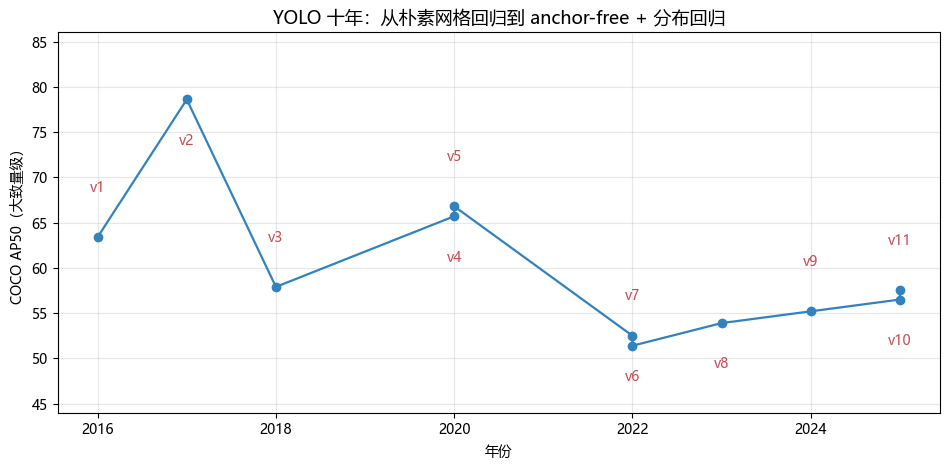

转折点标注：v3 多尺度(2018)、v5 工程化(2020)、v8 anchor-free(2023) —— 三次范式级变化


In [19]:
# ========== 图：YOLO 演进时间线（AP50 大致轨迹 + 关键转折点） ==========
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

years = [2016, 2017, 2018, 2020, 2020, 2022, 2022, 2023, 2024, 2025, 2025]
aps =   [63.4, 78.6, 57.9, 65.7, 66.8, 52.5, 51.4, 53.9, 55.2, 56.5, 57.5]  # 各自报告的最优 AP50 档（COCO，v5 微调示意见）
names = ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11']
fig, ax = plt.subplots(figsize=(9.6, 4.8))
ax.plot(years, aps, '-o', color='#3182bd', lw=1.6, ms=6)
# 标签直接放在数据坐标（±5 单位交替上下）：同年份成对的文本框（高约 1.6 单位）间距 10 单位，绝不叠字
for i, (x, y, n) in enumerate(zip(years, aps, names)):
    ly = y + (5.0 if i % 2 == 0 else -5.0)
    ax.text(x, ly, n, ha='center', fontsize=10, color='#C44E52')
ax.set_xlabel('年份'); ax.set_ylabel('COCO AP50（大致量级）')
ax.set_title('YOLO 十年：从朴素网格回归到 anchor-free + 分布回归', fontsize=13)
ax.set_ylim(44, 86); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('转折点标注：v3 多尺度(2018)、v5 工程化(2020)、v8 anchor-free(2023) —— 三次范式级变化')

## §10 数字敏感度与易错点（扩展背诵）

**数字**
- v1：S=7、B=2、448 输入、输出 7×7×30（PASCAL 20 类）、λ_coord=5、λ_noobj=0.5
- v2：anchor K=5、Darknet-19、检测分辨率 480
- v3：Darknet-53、stride 8/16/32 → 52/26/13、anchor 9 个（3 尺度 × 3 比例）、COCO 每尺度输出 255
- v4：CSP、Mish、Mosaic、CIoU、自对抗训练
- v8：anchor-free 4 距离 + DFL 16 bin + TaskAlignedAssigner（β=6、α=0.5）
- v9：PGI 辅助可逆分支；v10：PSA 部分通道自注意力；v11：C2PSA/Mamba

**易错点**
1. $w/h$ 开根号是「对 √w、√h 做 MSE」，不是平方根损失本身
2. anchor 聚类用 IoU 距离，不是欧氏（大框带偏）
3. encode $t_w=\log(w/a_w)$、decode 必须 $\exp$ 回去——漏了框就缩没了
4. v3 的大特征图（stride 8）管**小物体**，别记反
5. v8 的 anchor-free 不是没有先验，而是回归「中心到四边」，免去锚框匹配
6. DFL 是期望回归：分布集中在某 bin 附近时给出亚 bin 精度

## §11 面试速答（30 秒背诵版 · 按故事线）

- **为什么 v1 开根号**：大小框的相对误差同等重视（绝对误差被大框主导）
- **为什么用 anchor**：直接回归绝对坐标难收敛；anchor 把任务变成「预测小偏移」
- **v2→v3 最大变化**：单尺度 → 多尺度 FPN（小物体漏检）+ 多标签 sigmoid
- **v4 的核心**：训练配方（Mosaic/CIoU/PANet/CSP），不是网络本身
- **v5 为什么流行**：工程化（auto-anchor/超参进化/一键部署），易用 > 论文
- **解耦头解决什么**：分类与回归任务冲突（共享头互相干扰）
- **v8 三件套**：anchor-free（四边距离）+ TaskAlignedAssigner（对齐度量 top-k）+ DFL（分布期望）
- **v9 PGI 是什么**：辅助可逆分支喂梯度，解决深网络梯度信息瓶颈
- **anchor-free 怎么做**：预测中心点到四边距离，decode 直接得框，无锚框匹配

## §12 知识链：本篇 → 哪里去？

- **向后**：`05/09 图像分割` —— 检测是框出物体，分割是像素级；U-Net 家族的跳连 = 检测的 FPN 思想在分割里的投影
- **再向后**：`10-SAM` —— 检测/分割都被「提示」（box/point）驱动，SAM 把分割做成了零样本对话
- **向前**：04 篇的 IoU/NMS/anchor/mAP 是本篇的零件库，不会就回去补
- **自测清单**
  - [ ] 默写 v1 损失五项与两个 λ
  - [ ] 手写 anchor 编解码 round-trip + 聚类（IoU 距离）
  - [ ] 手写 CIoU 三惩罚项；画损失随错开量曲线
  - [ ] 手写 v8 decode（中心到四边）+ DFL 期望回归
  - [ ] 讲清 v1→v11 每条故事线（痛点→方案→新痛点）
  - [ ] 口算：416 图 stride 32 → 13×13 网格、每格 255 通道